# LCU
The Linear Combination of Unitaries (LCU) is a foundational protocol in quantum computing that allows us to apply a non-unitary matrix to a quantum state by breaking it down into a sum of unitary matrices. 

Here is the complete step-by-step mathematical derivation of how the LCU protocol successfully applies this operation, utilizing the transpose of the state preparation matrix to preserve complex coefficients. We will track the state of the quantum computer at each distinct step using the sequence $|\Phi_0\rangle, |\Phi_1\rangle, |\Phi_2\rangle$, and $|\Phi_3\rangle$.

### The Mathematical Setup

We want to apply a non-unitary target matrix $A$ to our data state, $|\psi\rangle$. 

First, we decompose $A$ into a sum of $N$ allowed unitary matrices ($U_k$), each weighted by a coefficient $\alpha_k$ (which can be complex):

$$A = \sum_{k=0}^{N-1} \alpha_k U_k$$

In our specific case, we utilize the Pauli matrices because they form a complete, orthogonal basis for the vector space of all $2 \times 2$ complex matrices. Furthermore, because the Pauli matrices are themselves unitary operators, this property guarantees that \textit{any} arbitrary $2 \times 2$ matrix $A$ can be perfectly decomposed into a linear combination of unitaries, which is the fundamental requirement of the LCU protocol.

Let $M_2(\mathbb{C})$ denote the vector space of all $2 \times 2$ complex matrices. The set of Pauli matrices, including the identity, is defined as:

$$ \sigma = \{\sigma_0, \sigma_1, \sigma_2, \sigma_3\} = \{I, X, Y, Z\} $$

This set forms a complete basis for $M_2(\mathbb{C})$. Therefore, any arbitrary matrix $A \in M_2(\mathbb{C})$ can be expressed as a linear combination of these matrices:

$$ A = \sum_{k=0}^{3} \alpha_k \sigma_k = \alpha_0 I + \alpha_1 X + \alpha_2 Y + \alpha_3 Z $$

Because the Pauli matrices are unitary ($\sigma_k^\dagger \sigma_k = I$), they perfectly satisfy the LCU requirement where $U_k = \sigma_k$. 

Furthermore the complex coefficients $\alpha_k$ for any target matrix $A$ can be easily and deterministically calculated using the formula:

$$ \alpha_k = \frac{1}{2} \text{Tr}(A \sigma_k) $$



To ensure the probabilities in our quantum system remain valid, we calculate a normalization constant $\lambda$, which is the sum of the absolute magnitudes of our coefficients:

$$\lambda = \sum_k |\alpha_k|$$

Finally, we define the amplitude weights $c_k$ that we will encode into our quantum state. We use the complex square root of the normalized coefficients:

$$c_k = \sqrt{\frac{\alpha_k}{\lambda}}$$

---

### Step 0: The Initial State ($|\Phi_0\rangle$)

We begin with two independent quantum registers:
1.  **The Ancilla Register:** An auxiliary "scratchpad" initialized to $|0\rangle$.
2.  **The Target Register:** Our actual data, initialized to $|\psi\rangle$.

The joint starting state of our system is simply the two registers side-by-side:

$$|\Phi_0\rangle = |0\rangle |\psi\rangle$$

---

### Step 1: State Preparation ($|\Phi_1\rangle$)

We apply a Preparation operator ($\text{PREP}$) exclusively to the ancilla register. The goal is to create a superposition where each branch corresponds to one of our unitaries, weighted by $c_k$. 

The operator is defined such that:

$$\text{PREP}|0\rangle = \sum_k c_k |k\rangle$$

Applying this to our initial state, we leave the target register unchanged. The new state of the entire system is:

$$|\Phi_1\rangle = \sum_k c_k |k\rangle |\psi\rangle$$

---

### Step 2: The Select Operation ($|\Phi_2\rangle$)

Next, we apply the Select operator ($\text{SEL}$). This is a massive, controlled operation that applies the unitary $U_k$ to the target register *if and only if* the ancilla register is in the state $|k\rangle$.

Mathematically, $\text{SEL}$ distributes across the superposition, entangling the specific unitaries with their corresponding ancilla states:

$$|\Phi_2\rangle = \text{SEL} |\Phi_1\rangle$$

$$|\Phi_2\rangle = \sum_k c_k |k\rangle U_k |\psi\rangle$$

At this moment, our desired operations are executing, but the results are trapped in an entangled superposition.

---

### Step 3: Transpose Post-Selection ($|\Phi_3\rangle$)


To extract the answer, we must decouple the ancilla from the target register. We achieve this physically through a strict two-step sequence: first applying a specific gate, and then filtering the results based on a measurement. 

Normally, to reverse a quantum state preparation, we would apply its inverse. Since quantum gates are unitary, the inverse is the conjugate transpose ($\text{PREP}^\dagger = \text{PREP}^{-1}$). However, if we do that here, the complex conjugation inherent to the $\dagger$ operation will conjugate our amplitudes and ruin the phase of our complex coefficients. 

To prevent this, we use the following sequence:

#### Apply the Transpose Gate
Instead of the inverse, we first apply only the \textbf{Transpose} of the preparation operator, $\text{PREP}^T$, to the ancilla register. (Note that for a unitary matrix, $\text{PREP}^T = \overline{\text{PREP}^{-1}}$). 

#### Measure and Post-Select
Immediately after applying $\text{PREP}^T$, we measure the ancilla register. We discard any runs where the ancilla measures as a $1$, and strictly keep the runs where the ancilla measures as a $0$ (a process known as post-selection).

#### Why do we do it this way?
In quantum mechanics, the physical act of applying an operator $M$ and then successfully post-selecting on the $|0\rangle$ state is mathematically equivalent to projecting the quantum state onto the "bra" vector $\langle 0|M$. 

Therefore, by physically applying $\text{PREP}^T$ and measuring $0$, we are mathematically applying the projection $\langle 0 | \text{PREP}^T$. 

Because a standard matrix transpose does \textit{not} involve complex conjugation, this specific sequence generates a "bra" vector that perfectly preserves our original complex amplitudes. Mathematically, we can express this projection as:




$$\langle 0 | \text{PREP}^T = \sum_j c_j \langle j |$$

We apply this projection to the ancilla portion of our entangled state to yield our final, unnormalized target state:

$$|\Phi_3\rangle = \left( \sum_j c_j \langle j | \right) |\Phi_2\rangle$$

$$|\Phi_3\rangle = \left( \sum_j c_j \langle j | \right) \left( \sum_k c_k |k\rangle U_k |\psi\rangle \right)$$

Because quantum basis states form an orthonormal basis ($\langle j | k \rangle = 1$ if $j=k$, and $0$ otherwise). This property collapses the double summation, isolating the terms where the branches match:

$$|\Phi_3\rangle = \sum_k c_k \cdot c_k U_k |\psi\rangle$$

$$|\Phi_3\rangle = \sum_k c_k^2 U_k |\psi\rangle$$

This is the crucial step. By squaring the complex amplitude $c_k$, we perfectly recover our original normalized coefficient:

$$c_k^2 = \left( \sqrt{\frac{\alpha_k}{\lambda}} \right)^2 = \frac{\alpha_k}{\lambda}$$

Substituting this back into the equation yields:

$$|\Phi_3\rangle = \sum_k \frac{\alpha_k}{\lambda} U_k |\psi\rangle$$

Factoring out the constant $\frac{1}{\lambda}$, we reveal our original non-unitary matrix $A$:

$$|\Phi_3\rangle = \frac{1}{\lambda} \sum_k \alpha_k U_k |\psi\rangle$$

$$|\Phi_3\rangle = \frac{A}{\lambda} |\psi\rangle$$

### The Result

By simply verifying that the ancilla register measures as $0$ at the end of the circuit, the mathematics guarantees that the target register has successfully collapsed into the state $|\Phi_3\rangle$. We have successfully applied an impossible, non-unitary operation to our quantum computer.

In [9]:
import numpy as np
A = np.array([[1, 2],
                [3, 4]])
I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

def calculate_alphas(A):

    alphas = np.array([np.trace(A @ sigma) for sigma in [I, X, Y, Z]]) / 2

    return alphas

print("Alphas:", calculate_alphas(A))

Alphas: [ 2.5+0.j   2.5+0.j   0. -0.5j -1.5+0.j ]


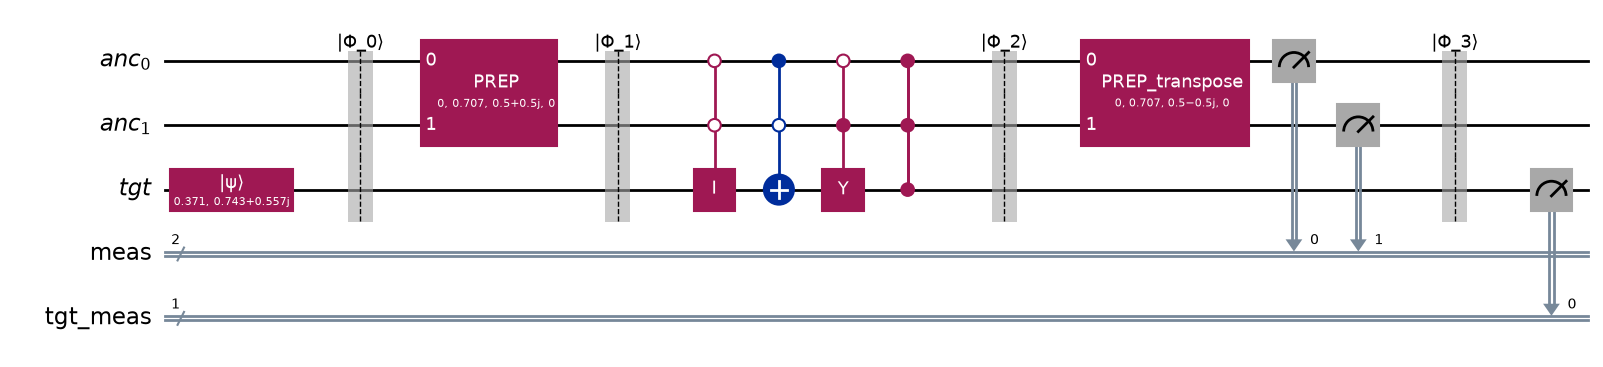

In [10]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import StatePreparation, XGate, YGate, ZGate, IGate


# coefficients for the ancilla state preparation
alphas = np.array([0,1,1j,0])  #A = alphas[0]I + alphas[1]X + alphas[2]Y + alphas[3]Z 
PSI = np.array([2, 4+3j], dtype=complex) #doesn't have to be normalized, it will be normalized in the next step

psi = PSI / np.linalg.norm(PSI)  # normalize the target state vector


amplitudes = np.array(alphas, dtype=complex)
lambda_ = np.abs(amplitudes).sum()
amplitudes = np.sqrt(amplitudes / lambda_) #PREP|0⟩
prep = StatePreparation(amplitudes, label='PREP')  
prep_transpose = StatePreparation(amplitudes.conjugate(), inverse=True) #PREP dagger conjugate = PREP transpose
prep_transpose.label = 'PREP_transpose'  # label the transpose preparation
psi_prep = StatePreparation(psi, label='|ψ⟩')


#setting up the quantum circuit
anc = QuantumRegister(2, name='anc')
tgt = QuantumRegister(1, name='tgt')
cr = ClassicalRegister(2, name='meas')
cr2 = ClassicalRegister(1, name='tgt_meas')
qc = QuantumCircuit(anc, tgt, cr, cr2)


#Step 0:
# prepare |ψ⟩ on the target qubit
qc.append(psi_prep, tgt)  
qc.barrier(label="|Φ_0⟩") #the state of the system is|Φ_0⟩

#Step 1:
# prepare ancilla qubits in the amplitude state given by the alphas
qc.append(prep, anc)  
qc.barrier(label="|Φ_1⟩") #the state of the system is|Φ_1⟩

#Step 2 (applying SEL):
ch_gate = IGate().control(2, ctrl_state='00')
qc.append(ch_gate, [anc[0], anc[1], tgt[0]])  # controlled-identity on target if ancilla is |00>

cx_gate = XGate().control(2, ctrl_state='01')
qc.append(cx_gate, [anc[0], anc[1], tgt[0]])  # controlled-X on target if ancilla is |01>

cy_gate = YGate().control(2, ctrl_state='10')
qc.append(cy_gate, [anc[0], anc[1], tgt[0]])  # controlled-Y on target if ancilla is |10>

cz_gate = ZGate().control(2, ctrl_state='11')
qc.append(cz_gate, [anc[0], anc[1], tgt[0]])  # controlled-Z on target if ancilla is |11>

qc.barrier(label="|Φ_2⟩") #the state of the system is|Φ_2⟩


#Step 3:
qc.append(prep_transpose, anc)  # uncompute the ancilla state
qc.measure(anc, cr)   # measure ancilla qubits

qc.barrier(label="|Φ_3⟩") #the state of the system is|Φ_3⟩ (if measured |00⟩ on ancilla)


qc.measure(tgt, cr2)  # measure target qubit
qc.draw('mpl')  # draw the circuit


# Draw the circuit
qc.draw('mpl')



probability of measuring |00⟩ on ancilla: 0.86208


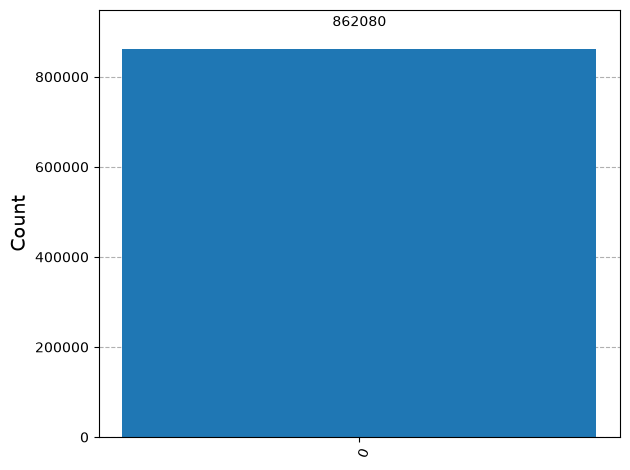

In [11]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import transpile


simulator = AerSimulator(shots=1000000)
compiled = transpile(qc, simulator).decompose()
job = simulator.run(compiled)
result = job.result()

counts = result.get_counts(compiled)
filtered_counts = {k: v for k, v in counts.items() if k.endswith('00')}
filtered_counts = {k.split()[0]: v for k, v in counts.items() if k.endswith('00')}
print("probability of measuring |00⟩ on ancilla:", sum(filtered_counts.values()) / sum(counts.values()))
plot_histogram(filtered_counts)



In [12]:
I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

A = alphas[0] * I + alphas[1] * X + alphas[2] * Y + alphas[3] * Z
result = A @ psi
result = result / np.linalg.norm(result)
probability = np.abs(result) ** 2
print("Result of A|ψ⟩:", result)
print("Probability of measuring |0⟩:", probability[0])
print("Probability of measuring |1⟩:", probability[1])
print("Measured probability of |0⟩ from the circuit:", filtered_counts.get('0', 0) / sum(filtered_counts.values()))
print("Measured probability of |1⟩ from the circuit:", filtered_counts.get('1', 0) / sum(filtered_counts.values()))



Result of A|ψ⟩: [0.8+0.6j 0. +0.j ]
Probability of measuring |0⟩: 0.9999999999999998
Probability of measuring |1⟩: 0.0
Measured probability of |0⟩ from the circuit: 1.0
Measured probability of |1⟩ from the circuit: 0.0
